In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from tqdm import trange

In [2]:
# generate synthetic dataset
def petals_value(die):
    if die == 3:
        return 2
    elif die == 5:
        return 4
    return 0

def generate_petals_data(N, k, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.integers(1, 7, size=(N, k))
    y = np.array([sum(petals_value(d) for d in row) for row in X])

    return X, y

In [3]:
# Generate data
X, y = generate_petals_data(N=10_000, k=5, seed=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

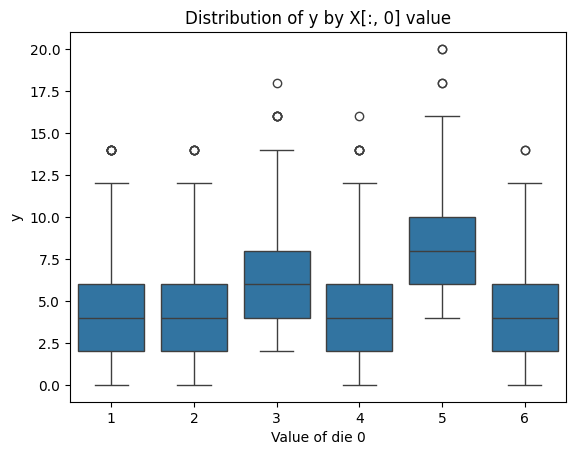

In [4]:
def plot_boxplot_by_die_value(X, y, i):
    df = pd.DataFrame({
        'die_value': X[:, i],
        'y': y
    })
    sns.boxplot(x='die_value', y='y', data=df)
    plt.title(f"Distribution of y by X[:, {i}] value")
    plt.xlabel(f"Value of die {i}")
    plt.ylabel("y")

plot_boxplot_by_die_value(X, y, 0)

In [5]:
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Define very simple neural network
model = nn.Sequential(
    nn.Linear(5, 100),
    nn.ReLU(),
    nn.Linear(100, 1),
)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.1)
        nn.init.constant_(m.bias, 0)
model.apply(init_weights)

# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train
losses = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

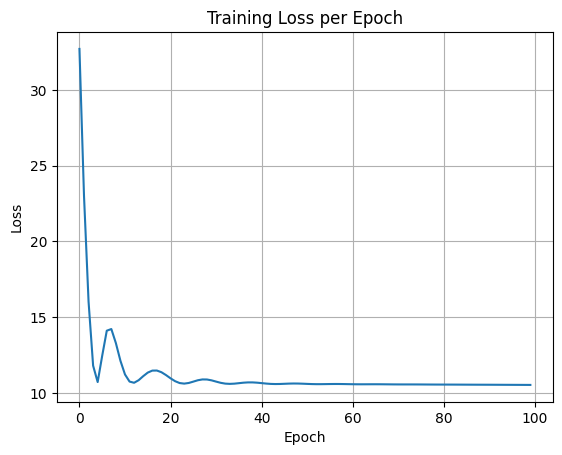

In [6]:
# Plot Training Loss
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.grid()

In [7]:
# Evaluate
model.eval()
with torch.no_grad():
    # Mean Absolute Error
    predictions = model(X_test)
    mae = torch.mean(torch.abs(predictions - y_test))
    print(f"Test MAE: {mae.item():.2f}")

    # Accuray
    accuracy = (predictions.round() == y_test).float().mean().item()
    print(f"Accuracy: {accuracy:.2%}")

Test MAE: 2.64
Accuracy: 10.70%


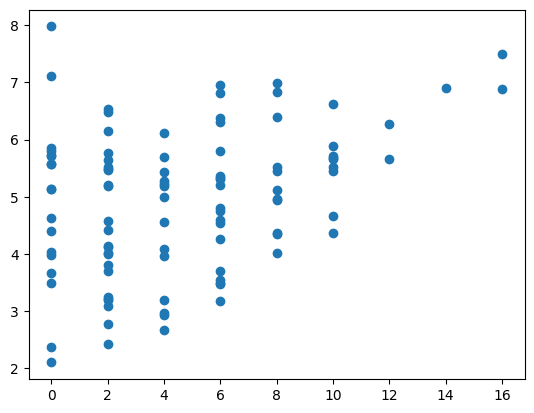

In [8]:
sample = 100
plt.scatter(y_test[:sample], predictions.numpy()[:sample]);

Training: 100%|█████████████████████████████████████████████████████████| 1000/1000 [01:27<00:00, 11.37it/s, loss=0.42]


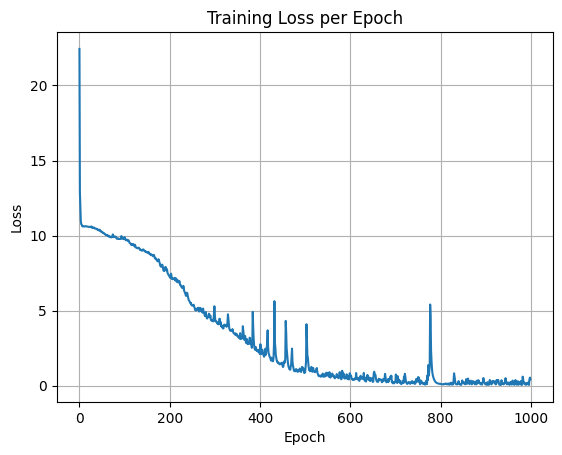

In [9]:
# Define a much larger and smarter model
model = nn.Sequential(
    nn.Linear(5, 100),
    nn.ReLU(),
    nn.Linear(100, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.1)
        nn.init.constant_(m.bias, 0)
model.apply(init_weights)

# Dataset and DataLoader with batch size
batch_size = 1024
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Training with early stopping by loss convergence
losses = []
tol = 1e-4
max_epochs = 1000

progress_bar = trange(max_epochs, desc="Training")

for epoch in progress_bar:
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(train_loader.dataset)
    losses.append(epoch_loss)
    progress_bar.set_postfix(loss=epoch_loss)

# Plot
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.grid()

In [14]:
# Evaluate
model.eval()
with torch.no_grad():
    # Mean Absolute Error
    predictions = model(X_test)
    mae = torch.mean(torch.abs(predictions - y_test))
    print(f"Test MAE: {mae.item():.2f}")

    # Accuracy
    accuracy = (predictions.round() == y_test).float().mean().item()
    print(f"Accuracy: {accuracy:.2%}")

Test MAE: 0.26
Accuracy: 87.65%


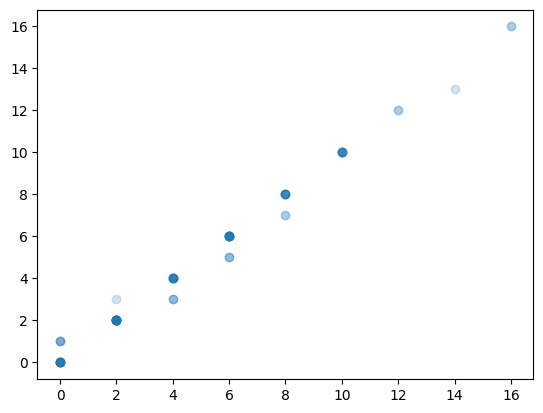

In [15]:
sample = 100
plt.scatter(y_test[:sample], predictions.numpy()[:sample].round(), alpha=0.2)

In [16]:
from pygam import LinearGAM, s, f
import numpy as np

# Assume X (N x 5), y are ready
gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4))
N_gam = 100
gam.fit(X[:N_gam, :], y[:N_gam])

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + intercept, tol=0.0001, 
   verbose=False)

In [17]:
# Evaluate GAM
predictions = gam.predict(X_test)
mae = np.mean(np.abs(predictions - y_test.numpy().flatten()))
print(f"Test MAE: {mae.item():.2f}")

# Accuracy
accuracy = (np.round(predictions) == y_test.numpy().flatten()).mean()
print(f"Accuracy: {accuracy:.2%}")

Test MAE: 0.09
Accuracy: 100.00%


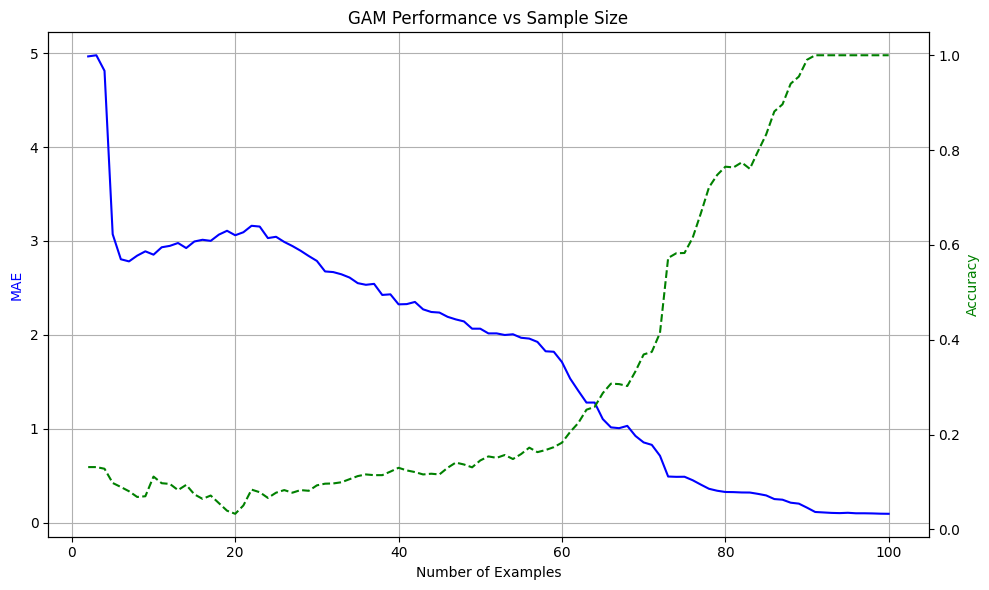

In [18]:
maes = []
accuracies = []

for n in range(2, 101):
    gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4))
    gam.fit(X[:n], y[:n])
    
    preds = gam.predict(X_test)
    y_true = y_test.numpy().flatten()

    mae = np.mean(np.abs(preds - y_true))
    acc = (np.round(preds) == y_true).mean()
    
    maes.append(mae)
    accuracies.append(acc)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()
ax1.plot(range(2, 101), maes, 'b-', label='MAE')
ax2.plot(range(2, 101), accuracies, 'g--', label='Accuracy')

ax1.set_xlabel('Number of Examples')
ax1.set_ylabel('MAE', color='b')
ax2.set_ylabel('Accuracy', color='g')
ax1.grid(True)

plt.title('GAM Performance vs Sample Size')
fig.tight_layout()

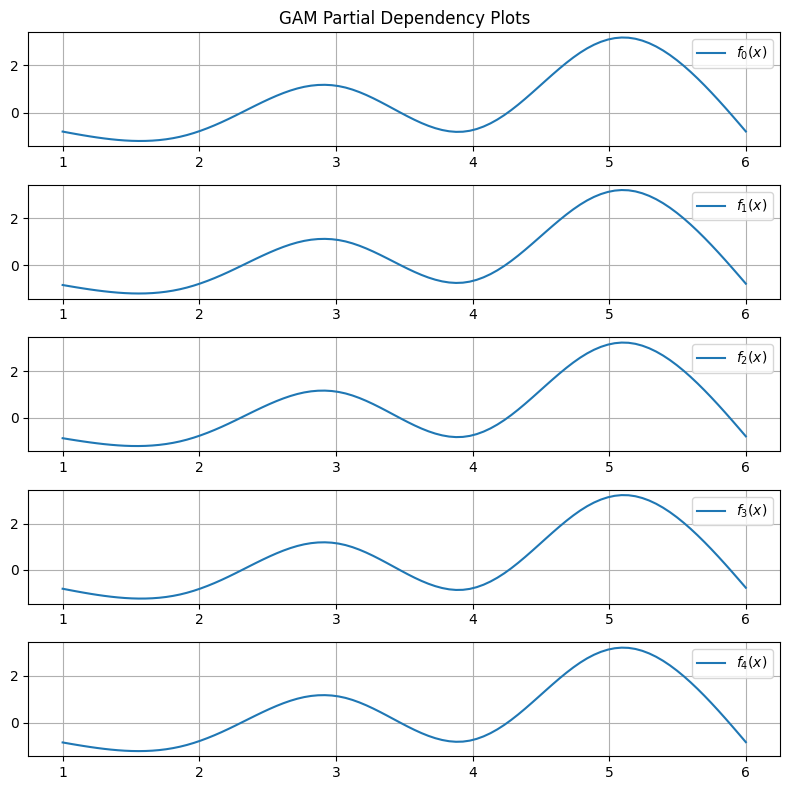

In [19]:
# Partial Dependency Plots
# Shows how the GAM has to "re-learn" the same curve idependently for each column
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8, 8))

for i in range(5):
    XX = gam.generate_X_grid(term=i)
    yy = gam.partial_dependence(term=i, X=XX)
    
    # Base line plot
    ax = axes[i]
    ax.plot(XX[:, i], yy, label=f"$f_{i}(x)$")

    #ax.set_title(f"Partial Dependence: $f_{i}(x)$")
    ax.grid(True)
    ax.legend()

    if i == 0:
        ax.set_title("GAM Partial Dependency Plots")

plt.tight_layout()

In [20]:
from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function
import numpy as np

# Define symbolic regressor
symbolic_regressor = SymbolicRegressor(
    function_set=["add", "mul"],
    population_size=1000,
    generations=100,
    stopping_criteria=0.0,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=1.0,
    verbose=1,
    parsimony_coefficient=0.001,
    random_state=42,
    n_jobs=8,
)

# Fit
symbolic_regressor.fit(X,  y.astype(float))

# Show best expression
print("Best program:", symbolic_regressor._program)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    24.68      7.61664e+20        5          2.87747              N/A      1.22m
   1     4.34          14.4476        5          2.82774              N/A     34.25s
   2     4.51          25.6822        5          2.82774              N/A     45.62s
   3     6.02          12997.1        5          2.82774              N/A     36.02s
   4     5.71          115.987        5          2.80819              N/A     42.58s
   5     5.08           173479        5          2.80819              N/A     57.22s
   6     5.09      3.55073e+06        5          2.80819              N/A     44.57s
   7     5.01          5.47008        7          2.79974              N/A     45.53s
   8     5.27           693800        7          2.78442              N/A  

In [21]:
# Mean Absolute Error
predictions = symbolic_regressor.predict(X_test)
mae = np.mean(np.abs(predictions - y_test.numpy().flatten()))
print(f"Test MAE: {mae.item():.2f}")

# Accuracy
accuracy = (np.round(predictions) == y_test.numpy().flatten()).mean()
print(f"Accuracy: {accuracy:.2%}")

Test MAE: 2.64
Accuracy: 11.75%
